## Bayesian Networks

### Alarm network in lab 1

First, we import the modules we need:

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn; seaborn.set_style('whitegrid')
import numpy

from pomegranate import *

numpy.random.seed(0)
numpy.set_printoptions(suppress=True)

%load_ext watermark
%watermark -m -n -p numpy,scipy,pomegranate

Wed Mar 18 2020 

numpy 1.16.2
scipy 1.2.1
pomegranate 0.11.0

compiler   : GCC 7.3.0
system     : Linux
release    : 4.15.0-88-generic
machine    : x86_64
processor  : x86_64
CPU cores  : 4
interpreter: 64bit


Now, we start building the network:

In [2]:
# Unconditional distribution for the metal node
metal = DiscreteDistribution({'T': 0.2, 'F': 0.8})

In [3]:
# Conditional distribution for the alarm devices
alarm1 = ConditionalProbabilityTable(
        [[ 'T', 'T', 0.9 ],
         [ 'T', 'F', 0.1 ],
         [ 'F', 'T', 0.3 ],
         [ 'F', 'F', 0.7 ]], [metal])  

In [4]:
m = State(metal, name="Metal weapon")
a1 = State(alarm1, name="Alarm #1")
a2 = State(alarm1, name="Alarm #2")

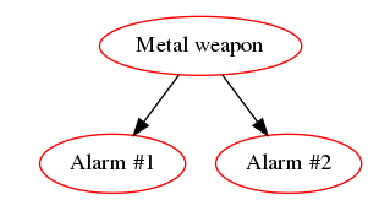

In [17]:
# Create the Bayesian network object
model = BayesianNetwork("Exercise 1: Alarm net")

# Add the states to the network 
model.add_states(m, a1, a2)

# Connect the states
model.add_edge(m, a1)
model.add_edge(m, a2)

# Integrate everything
model.bake()

#Draw the network
model.plot()

Interrogate the net:

John carries a gun and both alarms go off.

In [6]:
model.probability(['T', 'T', 'T'])

0.162

Probability that John is carrying a weapon:

In [7]:
model.probability(['T', None, None])

0.2

The second alarm goes go off, the first one does not. Probability that John has a gun: 

In [8]:
model.predict_proba({'Alarm #1': 'F', 'Alarm #2': 'T'})

array([{
    "class" :"Distribution",
    "dtype" :"str",
    "name" :"DiscreteDistribution",
    "parameters" :[
        {
            "T" :0.09677419354838795,
            "F" :0.903225806451612
        }
    ],
    "frozen" :false
},
       'F', 'T'], dtype=object)

John has a gun and both alarms go off:

In [9]:
model.probability(['T', 'T', 'T'])

0.162

Probability that John carries a gun if we know that both alarms go off:

In [10]:
model.predict_proba({'Alarm #1': 'T', 'Alarm #2': 'T'})

array([{
    "class" :"Distribution",
    "dtype" :"str",
    "name" :"DiscreteDistribution",
    "parameters" :[
        {
            "T" :0.6923076923076925,
            "F" :0.30769230769230743
        }
    ],
    "frozen" :false
},
       'T', 'T'], dtype=object)

Probability that both alarms go off:

In [11]:
model.probability(['T', 'T', 'T']) + model.probability(['F', 'T', 'T'])

0.23399999999999999

In [12]:
model.marginal()

array([{
    "class" :"Distribution",
    "dtype" :"str",
    "name" :"DiscreteDistribution",
    "parameters" :[
        {
            "T" :0.2000000000000005,
            "F" :0.7999999999999995
        }
    ],
    "frozen" :false
},
       {
    "class" :"Distribution",
    "dtype" :"str",
    "name" :"DiscreteDistribution",
    "parameters" :[
        {
            "T" :0.42000000000000026,
            "F" :0.5799999999999996
        }
    ],
    "frozen" :false
},
       {
    "class" :"Distribution",
    "dtype" :"str",
    "name" :"DiscreteDistribution",
    "parameters" :[
        {
            "T" :0.42000000000000026,
            "F" :0.5799999999999996
        }
    ],
    "frozen" :false
}], dtype=object)

What is this?

In [13]:
model.predict_proba([None, 'T', 'T'])

array([{
    "class" :"Distribution",
    "dtype" :"str",
    "name" :"DiscreteDistribution",
    "parameters" :[
        {
            "T" :0.6923076923076925,
            "F" :0.30769230769230743
        }
    ],
    "frozen" :false
},
       'T', 'T'], dtype=object)

Probability that the first alarm goes off:

In [14]:
model.probability(['T','T','T']) + model.probability(['T','T','F']) + model.probability(['F','T','T']) + model.probability(['F','T','F'])

0.42

What is this?

In [15]:
model.predict_proba({'Alarm #1': 'T'})

array([{
    "class" :"Distribution",
    "dtype" :"str",
    "name" :"DiscreteDistribution",
    "parameters" :[
        {
            "T" :0.428571428571429,
            "F" :0.5714285714285708
        }
    ],
    "frozen" :false
},
       'T',
       {
    "class" :"Distribution",
    "dtype" :"str",
    "name" :"DiscreteDistribution",
    "parameters" :[
        {
            "T" :0.5571428571428575,
            "F" :0.44285714285714267
        }
    ],
    "frozen" :false
}], dtype=object)

What is this? 

In [16]:
model.probability([None,'T',None])

1.0